<a href="https://colab.research.google.com/github/santoshs0612/Foundational-Math-in-ML/blob/main/DataVisualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Visualization

### MatplotLib


In [14]:
import matplotlib.pyplot as plt
epochs = [1,2,3,4,5]
train_loss = [0.9,0.6,0.5,0.4,0.35]
val_loss = [1.0,0.7,0.6,0.5,0.45]

<function matplotlib.pyplot.show(close=None, block=None)>

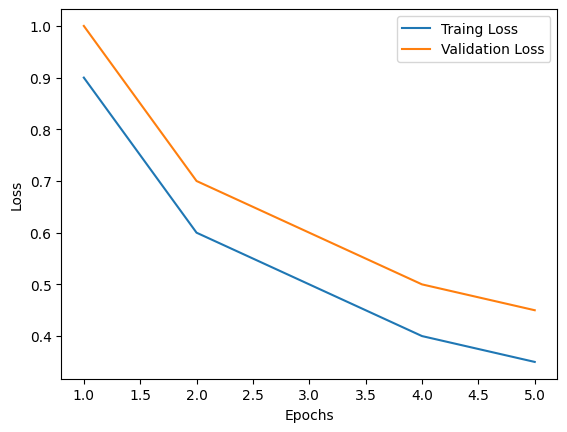

In [15]:
plt.plot(epochs,train_loss,label = "Traing Loss")
plt.plot(epochs,val_loss,label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show

### BarChart

Text(0, 0.5, 'Counts')

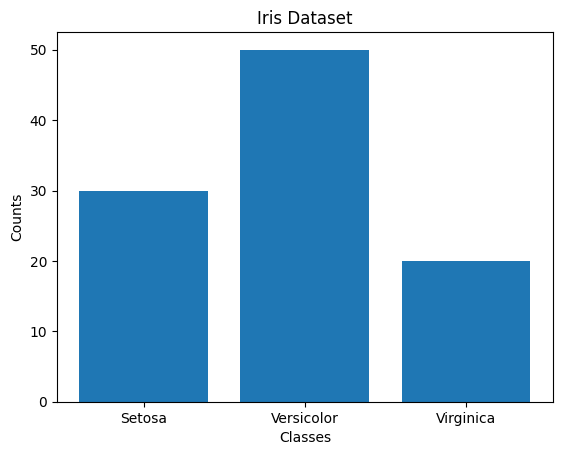

In [16]:
classes = ['Setosa','Versicolor','Virginica']
counts = [30,50,20]
plt.bar(classes,counts)
plt.title("Iris Dataset")
plt.xlabel("Classes")
plt.ylabel("Counts")

### Histogram

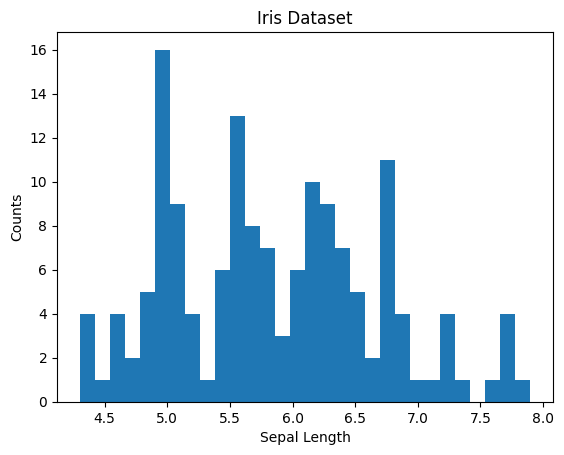

In [17]:
import seaborn as sns

df = sns.load_dataset("iris")
# df.head()
plt.hist(df["sepal_length"], bins=30)
plt.title("Iris Dataset")
plt.xlabel("Sepal Length")
plt.ylabel("Counts")
plt.show()

### Scatter Plot

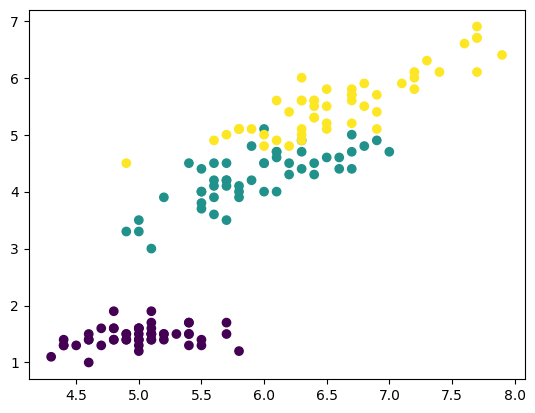

In [18]:
plt.scatter(df["sepal_length"],df["petal_length"], c = df['species'].astype('category').cat.codes)

## SeaBorn - Statistical and ML-Friendly Plots

### Count Plot - Target class Distribution

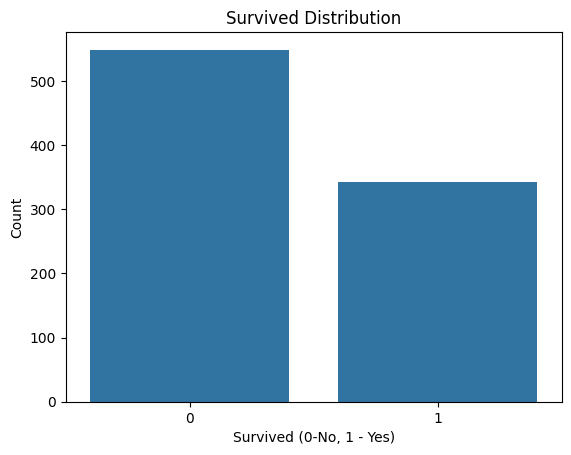

In [19]:
import seaborn as sns
df2 = sns.load_dataset('titanic')
# df.head()
sns.countplot(x='survived',data= df2)
plt.title("Survived Distribution")
plt.xlabel("Survived (0-No, 1 - Yes)")
plt.ylabel("Count")
plt.show()

### Box Plot

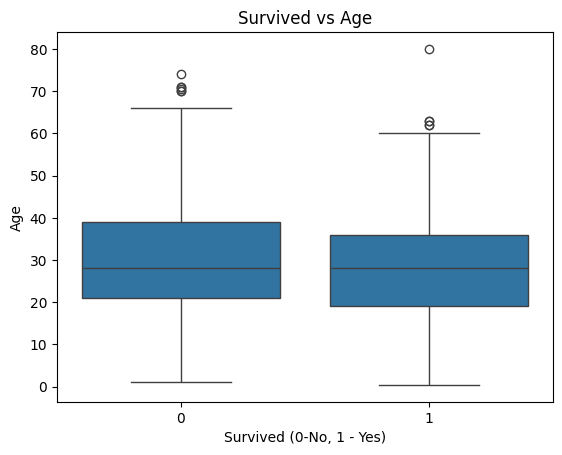

In [20]:
sns.boxplot(x='survived',y='age',data= df2)
plt.title("Survived vs Age")
plt.xlabel("Survived (0-No, 1 - Yes)")
plt.ylabel("Age")
plt.show()
#

### Violine Plot - Class-wise Distributions

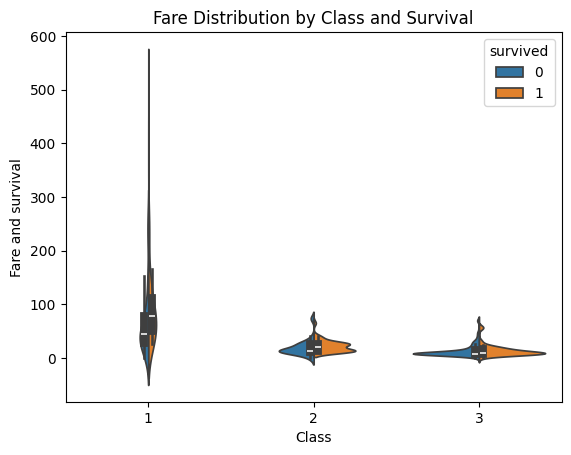

In [22]:
sns.violinplot(x = 'pclass', y ='fare',hue='survived',split=True, data = df2)
plt.title("Fare Distribution by Class and Survival")
plt.xlabel("Class")
plt.ylabel("Fare and survival")
plt.show()

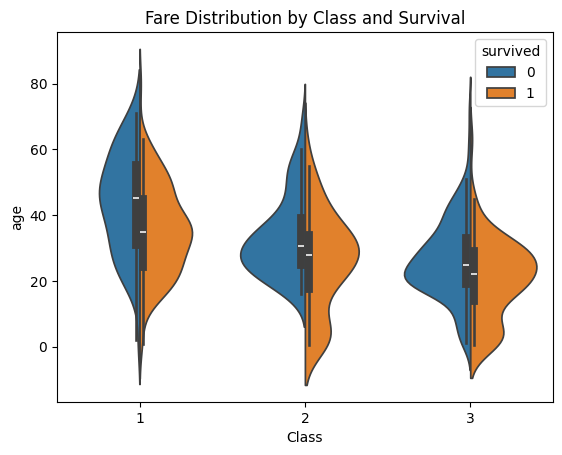

In [23]:
sns.violinplot(x = 'pclass', y ='age',hue='survived',split=True, data = df2)
plt.title("Fare Distribution by Class and Survival")
plt.xlabel("Class")
plt.ylabel("age")
plt.show()

### Heat Map - Correlation

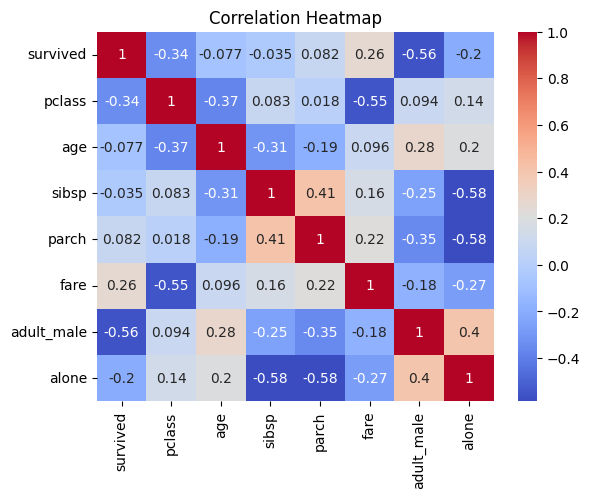

In [24]:
corr = df2.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Pair Plot- Multivariate Analysis

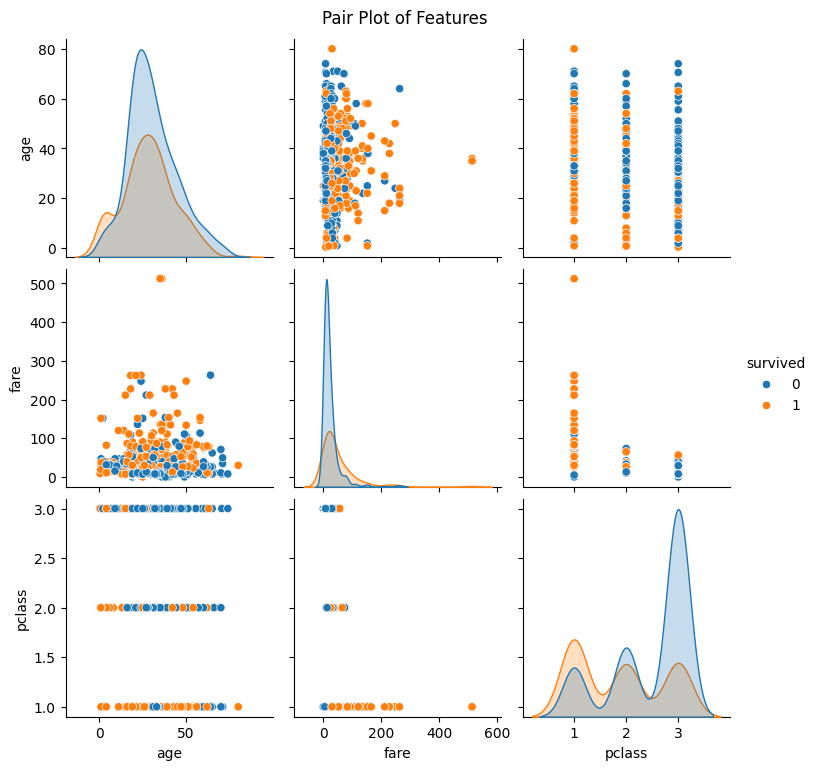

In [25]:
sns.pairplot(df2[['age','fare','pclass','survived']].dropna(),hue='survived')
plt.suptitle("Pair Plot of Features",y= 1.02)
plt.show()

## Plotely - For interactive visualization

### Heat Map - Correlation Matrix

In [27]:
import plotly.express as px
fig = px.scatter(df2, x = 'age', y = 'fare',color = 'survived',size = 'pclass',hover_data= ['sex','embarked'], title= "Interactive Titanic Plot")
fig.show()
#

### 2-D scatter Plot

In [28]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter(df,x = "sepal_width",y = "sepal_length",color = "species",size = "petal_length")
fig.show()


### 3-D Scatter Plot

In [29]:
fig = px.scatter_3d(df,x = "sepal_width",y = "sepal_length",z = "petal_length",color = "species",size = "petal_length")
fig.show()
#

## Titanic Dataset Exploratory Data Analysis(EDA)

In [30]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Load the titanic data
df = sns.load_dataset("titanic")
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Basic Data cleanup

In [35]:
# Drop  less Usefull or high missing columns
df.drop(columns=['deck','embark_town'],inplace=True, errors='ignore')

# Fill missing age with median
df['age'].fillna(df['age'].median(),inplace=True)
#fill embark with mode
df['embarked'].fillna(df['embarked'].mode()[0],inplace=True)
# Drop rows with any remaing missing values
df.dropna(inplace=True)
# confirm cleanup
df.isnull().sum()

/tmp/ipykernel_296/4075512570.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_296/4075512570.py:7: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or d

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    891 non-null    int64   
 1   pclass      891 non-null    int64   
 2   sex         891 non-null    object  
 3   age         891 non-null    float64 
 4   sibsp       891 non-null    int64   
 5   parch       891 non-null    int64   
 6   fare        891 non-null    float64 
 7   embarked    891 non-null    object  
 8   class       891 non-null    category
 9   who         891 non-null    object  
 10  adult_male  891 non-null    bool    
 11  alive       891 non-null    object  
 12  alone       891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(4)
memory usage: 72.5+ KB


### Univariate Analysis


#### Survival Count

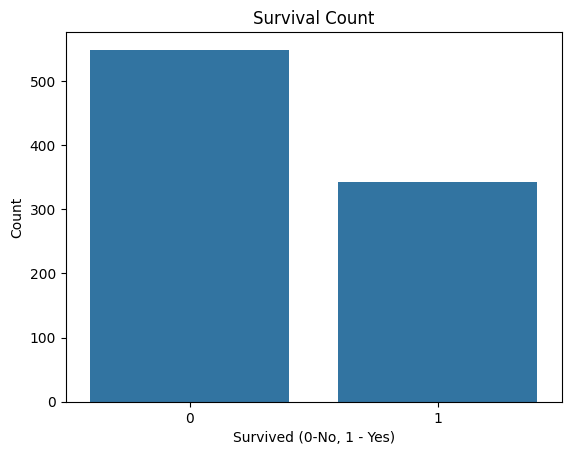

In [37]:
sns.countplot(x='survived',data= df)
plt.title("Survival Count")
plt.xlabel("Survived (0-No, 1 - Yes)")
plt.ylabel("Count")
plt.show()

#### Histogram Plot

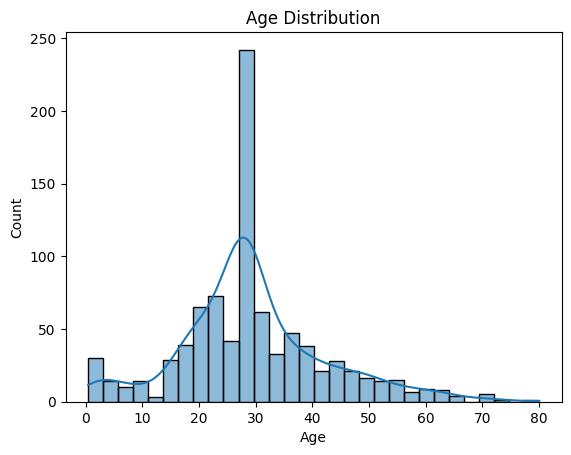

In [38]:
sns.histplot(df['age'],kde = True,bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()
#

#### P Class distributions

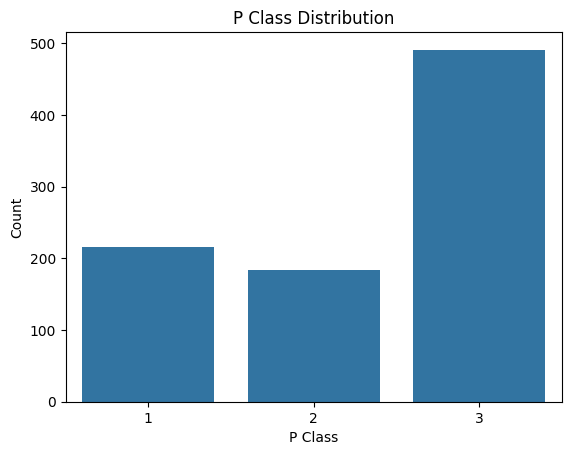

In [39]:
sns.countplot(x='pclass',data= df)
plt.title("P Class Distribution")
plt.xlabel("P Class")
plt.ylabel("Count")
plt.show()
#

### Bivariate Analysis

#### Gender Vs Survival

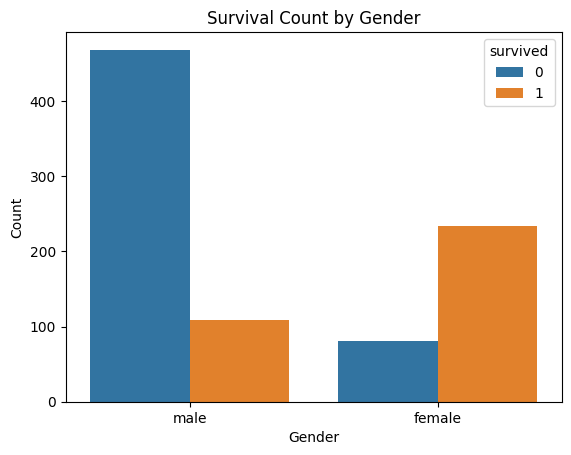

In [40]:
sns.countplot(x='sex',hue='survived',data= df)
plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()
#

### Feature Engineering

In [41]:
df['is_child'] = df['age'] < 16
df['FamilySize'] = df['sibsp'] + df['parch'] + 1
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone,is_child,FamilySize
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,no,False,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,yes,False,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,yes,True,False,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,yes,False,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,no,True,False,1


#### Saving the data

In [42]:
df.to_csv('titanic_cleaned.csv',index=False)